In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [2]:
df = pd.read_csv("pizza_sales.csv")

In [ ]:
df.head()

In [4]:
print("Shape : ",df.shape)

Shape :  (48620, 12)


#### Total Revenue

In [141]:
total_revenue = df["total_price"].sum()
print(f"Total Revenue : ${total_revenue:,.2f}")

Total Revenue : $817,860.05


#### Total Pizza Sold

In [133]:
total_pizza_sold = df["quantity"].sum()
print("Total Pizza Sold : ",total_pizza_sold)

Total Pizza Sold :  49574


#### Total Orders

In [7]:
total_orders = df["order_id"].nunique()
print(total_orders)

21350


#### Average Orders

In [140]:
average_orders = total_revenue / total_orders
print(f"Average Order : ${average_orders:,.2f}")

Average Order : $38.31


#### Total Pizza Orders

In [138]:
average_pizza_orders = total_pizza_sold / total_orders
print(f"Average Pizza Order : {average_pizza_orders:,.2f}")

Average Pizza Order : 2.32


In [10]:
from datetime import datetime

In [11]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="%d-%m-%Y"
)

In [12]:
df["new_date"] = df["order_date"].dt.day_name()
order_by_day = df.groupby("new_date")["total_price"].sum()
order_by_day

new_date
Friday       136073.90
Monday       107329.55
Saturday     123182.40
Sunday        99203.50
Thursday     123528.50
Tuesday      114133.80
Wednesday    114408.40
Name: total_price, dtype: float64

In [13]:
df["new_date"].value_counts()

new_date
Friday       8106
Saturday     7355
Thursday     7323
Wednesday    6797
Tuesday      6753
Monday       6369
Sunday       5917
Name: count, dtype: int64

In [14]:
ingredient = (df["pizza_ingredients"]
    .str.split(",")
    .explode()
    .str.split()
    .value_counts()
    .reset_index()
    .rename(columns={"index":"Ingerdeints" , "pizza_ingredeints" : "counts"})
    )

In [15]:
ingredient.head(10)

,pizza_ingredients,count
0,[Garlic],27422
1,[Tomatoes],26601
2,"[Red, Onions]",19547
3,"[Red, Peppers]",16284
4,"[Mozzarella, Cheese]",10333
5,[Pepperoni],10300
6,[Spinach],10012
7,[Mushrooms],9624
8,[Chicken],8443
9,[Capocollo],6572


#### Total Orders by Day

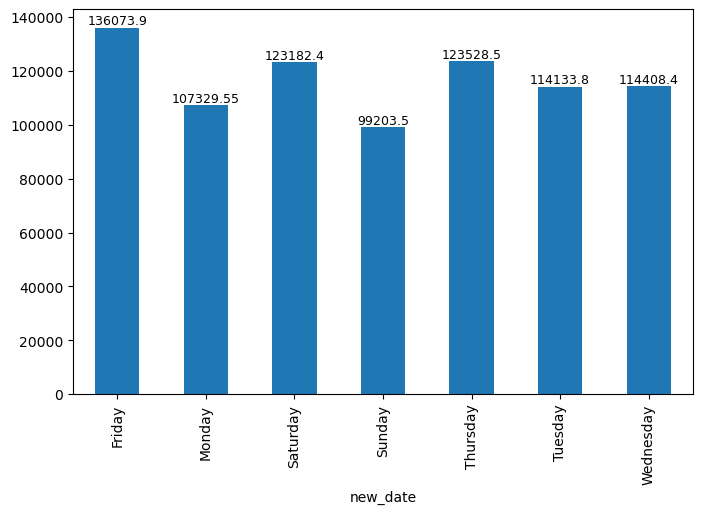

In [16]:
order_by_day.plot(kind = "bar" , figsize=(8,5))
for i, val in enumerate(order_by_day):
    plt.text(i,val+20,str(val) , ha="center" , fontsize = 9 , va = "bottom")

In [146]:
df["order_time"] = pd.to_datetime(df["order_time"])

In [18]:
df["hour"] = df["order_time"].dt.hour

In [19]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,new_date,hour
0,1,1,hawaiian_m,1,2015-01-01,2026-05-18 11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,Thursday,11
1,2,2,classic_dlx_m,1,2015-01-01,2026-05-18 11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,Thursday,11
2,3,2,five_cheese_l,1,2015-01-01,2026-05-18 11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,Thursday,11
3,4,2,ital_supr_l,1,2015-01-01,2026-05-18 11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,Thursday,11
4,5,2,mexicana_m,1,2015-01-01,2026-05-18 11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,Thursday,11


#### Total Orders by Hours

In [20]:
order_by_hours = df.groupby(["hour"])["order_id"].nunique()

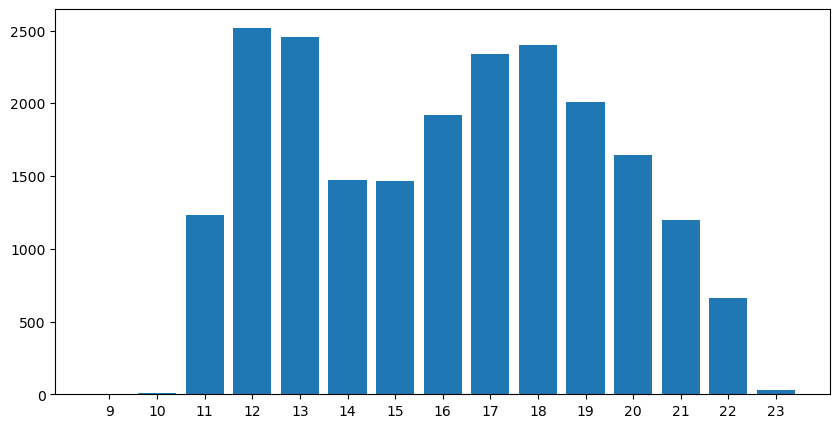

In [21]:
plt.figure(figsize=(10,5))

plt.bar(
    order_by_hours.index.astype(str),
    order_by_hours.values
)

plt.show()

#### Total Orders by Months

In [22]:
df["month"] = df["order_date"].dt.month_name()

In [23]:
order_by_months = df.groupby("month")["order_id"].nunique()

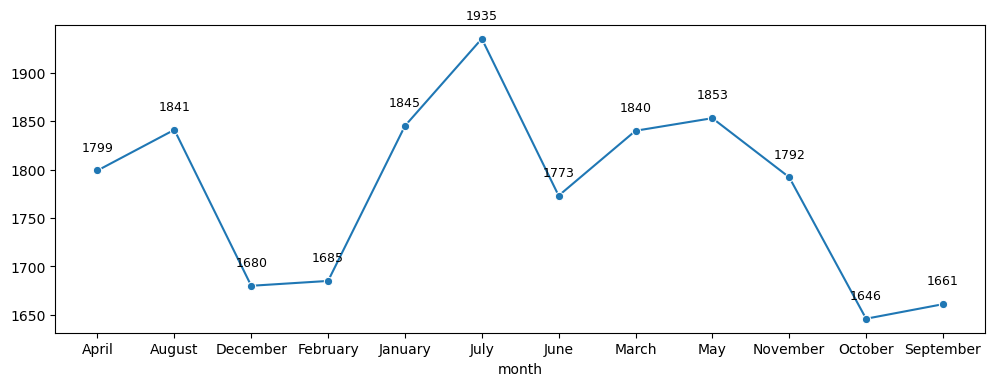

In [24]:
plt.figure(figsize=(12,4))
sns.lineplot(x=order_by_months.index , y=order_by_months.values, marker="o")
for i, val in enumerate(order_by_months):

    plt.text(i,val+20,str(val) , ha="center" , fontsize = 9  )

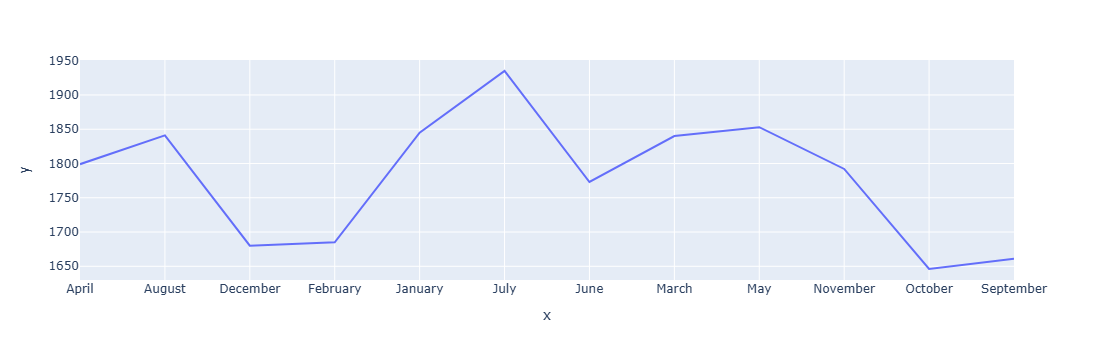

In [25]:
px.line(x=order_by_months.index , y=order_by_months.values)

#### % Sales by Category

In [28]:
sales_by_category = df.groupby(df["pizza_category"])["total_price"].sum()

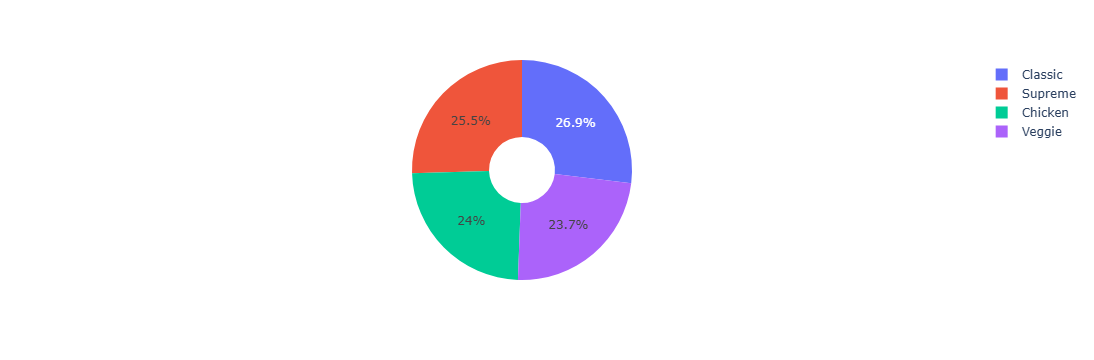

In [39]:
px.pie(sales_by_category , names=sales_by_category.index , values=sales_by_category.values, hole=0.3)

#### Total Sales by Size

In [57]:
sales_by_size = df.groupby(df["pizza_size"])["total_price"].sum()

In [68]:
quantity_by_revenue = df.groupby(df["pizza_size"])["quantity"].count()

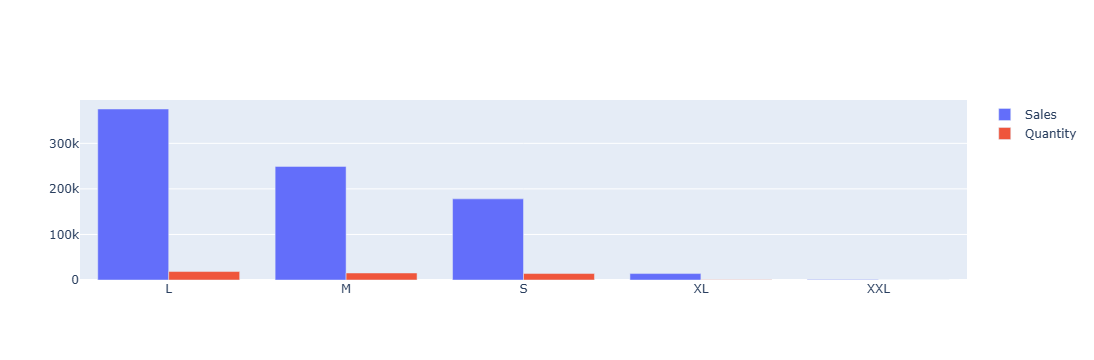

In [69]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_bar(
    x=sales_by_size.index,
    y=sales_by_size.values,
    name="Sales"
)

fig.add_bar(
    x=quantity_by_revenue.index,
    y=quantity_by_revenue.values,
    name="Quantity"
)

fig.update_layout(barmode="group")

fig.show()

#### % Sales by Pizza Size and Category

In [91]:
sales_pivot = df.pivot_table(index="pizza_category" , columns="pizza_size" , values="total_price" , aggfunc="sum" , fill_value=0)
sales_pvt = sales_pivot / sales_pivot.sum() * 100

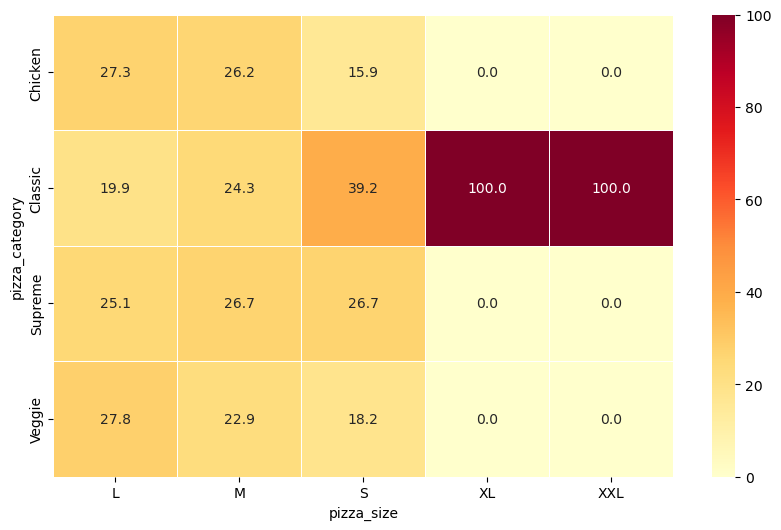

In [93]:
plt.figure(figsize=(10,6))
sns.heatmap(
    sales_pvt,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.show()

In [134]:
print("S size and Classic category of pizza perform best")

S size and Classic category of pizza perform best


In [94]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,new_date,hour,month
0,1,1,hawaiian_m,1,2015-01-01,2026-05-18 11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,Thursday,11,January
1,2,2,classic_dlx_m,1,2015-01-01,2026-05-18 11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,Thursday,11,January
2,3,2,five_cheese_l,1,2015-01-01,2026-05-18 11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,Thursday,11,January
3,4,2,ital_supr_l,1,2015-01-01,2026-05-18 11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,Thursday,11,January
4,5,2,mexicana_m,1,2015-01-01,2026-05-18 11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,Thursday,11,January


#### Total Pizza Sold by Category

In [97]:
piza_sold_by_category = df.groupby("pizza_category")["quantity"].sum()
piza_sold_by_category

pizza_category
Chicken    11050
Classic    14888
Supreme    11987
Veggie     11649
Name: quantity, dtype: int64

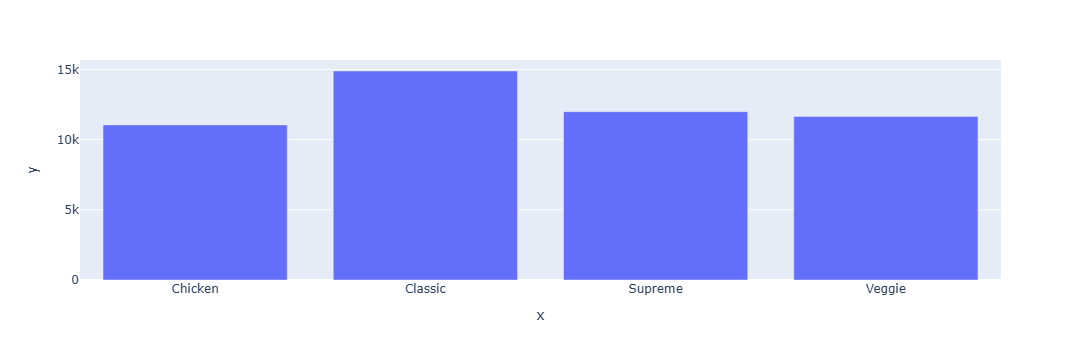

<Figure size 1000x700 with 0 Axes>

In [104]:
plt.figure(figsize=(10,7))
px.bar(x=piza_sold_by_category.index , y=piza_sold_by_category.values)

In [105]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,new_date,hour,month
0,1,1,hawaiian_m,1,2015-01-01,2026-05-18 11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,Thursday,11,January
1,2,2,classic_dlx_m,1,2015-01-01,2026-05-18 11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,Thursday,11,January
2,3,2,five_cheese_l,1,2015-01-01,2026-05-18 11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,Thursday,11,January
3,4,2,ital_supr_l,1,2015-01-01,2026-05-18 11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,Thursday,11,January
4,5,2,mexicana_m,1,2015-01-01,2026-05-18 11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,Thursday,11,January


#### Top 5 best Selling Pizza

In [117]:
piza_sold_by_revenue = df.groupby("pizza_name")["quantity"].sum()
piza_sold_by_revenue
top5 = piza_sold_by_revenue.sort_values(ascending=False).head(5)
top5

pizza_name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

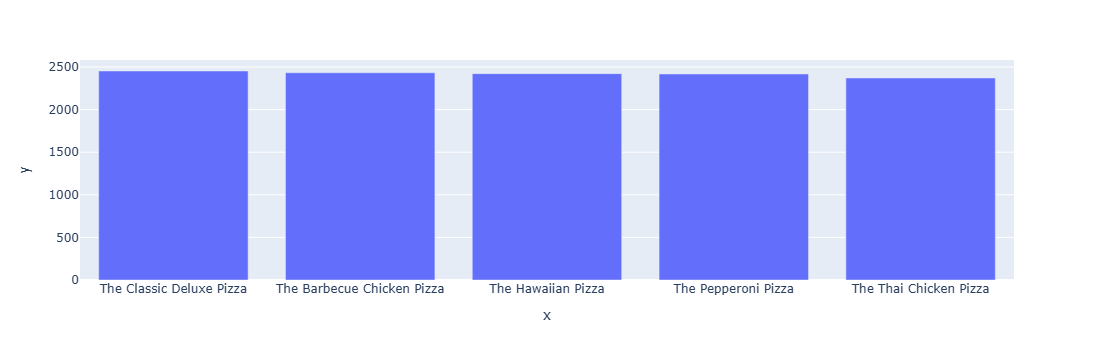

In [118]:
px.bar(x=top5.index , y=top5.values)

#### Bottom 5 Least-Selling Pizza

In [127]:
piza_less_sold_by_revenue = df.groupby("pizza_name")["total_price"].sum()
piza_less_sold_by_revenue


pizza_name
The Barbecue Chicken Pizza                    42768.00
The Big Meat Pizza                            22968.00
The Brie Carre Pizza                          11588.50
The Calabrese Pizza                           15934.25
The California Chicken Pizza                  41409.50
The Chicken Alfredo Pizza                     16900.25
The Chicken Pesto Pizza                       16701.75
The Classic Deluxe Pizza                      38180.50
The Five Cheese Pizza                         26066.50
The Four Cheese Pizza                         32265.70
The Greek Pizza                               28454.10
The Green Garden Pizza                        13955.75
The Hawaiian Pizza                            32273.25
The Italian Capocollo Pizza                   25094.00
The Italian Supreme Pizza                     33476.75
The Italian Vegetables Pizza                  16019.25
The Mediterranean Pizza                       15360.50
The Mexicana Pizza                            26780.75

In [143]:
top5_least = piza_less_sold_by_revenue.sort_values(ascending=True).head(5)
top5_least

pizza_name
The Brie Carre Pizza         11588.50
The Green Garden Pizza       13955.75
The Spinach Supreme Pizza    15277.75
The Mediterranean Pizza      15360.50
The Spinach Pesto Pizza      15596.00
Name: total_price, dtype: float64

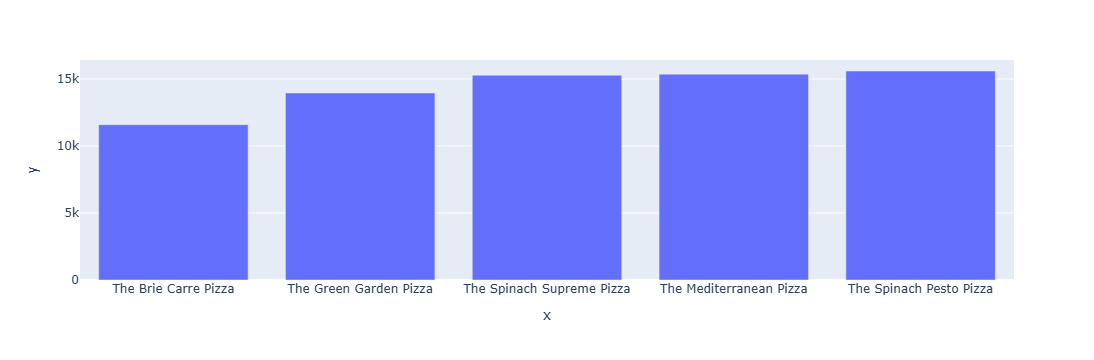

In [144]:
px.bar(x=top5_least.index , y=top5_least.values)

In [145]:
print("Top perfoemance is The Classic Delux Pizza and bottom performance is The Brie Carre Pizza")

Top perfoemance is The Classic Delux Pizza and bottom performance is The Brie Carre Pizza
